# Employee Promotion Prediction Engine

**Dataset:** [HR Analytics: Employee Promotion (Kaggle)](https://www.kaggle.com/datasets/arashnic/hr-ana)

**Notebook Map (who owns what):**

| Section | Topic | Owner |
|---|---|---|
| 1 | Problem Statement & Dataset Overview | Imaan Mutayyab |
| 2 | Data Cleaning & Quality Audit |Imaan Mutayyab |
| 3 | Exploratory Data Analysis (EDA) | Imaan Mutayyab |
| 4 | Feature Engineering & Baseline Model (Logistic Regression) | Nimra Farooq|
| 5 | Advanced Modeling (Random Forest) |Sofia Rashid |
| 6 | Dashboard Development (Streamlit) | Nimra Farooq & Imaan Mutayyab |
| 7 | Conclusion & Final Comparison | Combined |


## 1. Problem Statement & Dataset Overview
**Section By:** Imaan Mutayyab

**Business Problem:**
Promotion decisions inside most organizations are inconsistent - shaped by manager bias, visibility, or who
advocates loudest for themselves, rather than purely by performance and readiness. This means employees who
are genuinely promotion-ready sometimes get overlooked, while HR has no systematic, data-backed way to flag
who is ready *before* the annual review cycle happens.

**Project Goal:**
Build a classification model that predicts whether an employee will be promoted, using performance ratings,
training scores, tenure, and past achievements - trained on real historical promotion outcomes as ground
truth, so the results are auditable and defensible rather than a guessed or circular label.

**Why This Matters:**
- Gives HR an objective, data-driven shortlist of promotion-ready employees ahead of review cycles
- Surfaces strong performers who might otherwise be passed over
- Feature importance makes the model's reasoning auditable, which matters given the fairness/compliance
  weight that promotion decisions carry

### 1.1 Data Acquisition

Before any modeling can happen, the raw data needs to be acquired, audited, and understood. This section
handles that first stage: pulling in the dataset, cleaning it, and running the initial EDA that surfaces
which features are worth engineering further and which patterns the model needs to account
for, such as class imbalance.


In [1]:
# Loading the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Dataset source: [HR Analytics: Employee Promotion (Kaggle)](https://www.kaggle.com/datasets/arashnic/hr-ana),
downloaded as `train.csv`. It contains ~54,800 employee records with real fields including department,
education, previous year rating, awards won, average training score, length of service, and the target
column `is_promoted`.


In [2]:
# Loading the dataset
df = pd.read_csv("train.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 54808 rows, 13 columns


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [3]:
# Structural overview: column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


**Note:** this particular download does **not** include a `KPIs_met >80%` column (some public mirrors of this dataset do).


In [4]:
#look at key numeric columns before any cleaning
df[['previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score']].describe()

,previous_year_rating,length_of_service,awards_won?,avg_training_score
count,50684.000000,54808.000000,54808.000000,54808.000000
mean,3.329256,5.865512,0.023172,63.386750
std,1.259993,4.265094,0.150450,13.371559
min,1.000000,1.000000,0.000000,39.000000
25%,3.000000,3.000000,0.000000,51.000000
50%,3.000000,5.000000,0.000000,60.000000
75%,4.000000,7.000000,0.000000,76.000000
max,5.000000,37.000000,1.000000,99.000000


## 2. Data Cleaning & Quality Audit
**Section By:** Imaan Mutayyab

Before any EDA is trustworthy, we run a full data-hygiene pass:
- Check and document missing values (before/after)
- Investigate *why* values are missing rather than blindly imputing
- Remove duplicate rows
- Confirm the dataset is clean and save it for Feature Engineering


In [6]:
# Missing Values BEFORE cleaning
missing_before = df.isnull().sum()
missing_before_pct = (missing_before / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %': missing_before_pct.round(2)
}).sort_values(by='Missing Count', ascending=False)

print("Missing Values BEFORE Cleaning:")
missing_report[missing_report['Missing Count'] > 0]

Missing Values BEFORE Cleaning:


,Missing Count,Missing %
previous_year_rating,4124,7.52
education,2409,4.40


#### Handling `previous_year_rating`

This is the field the team flagged as needing careful handling. Rather than filling it with the median or mean (which would fabricate a performance signal that doesn't exist), we first test a hypothesis: are these missing ratings concentrated among **new hires** who haven't completed a review cycle yet?


In [7]:
# Test hypothesis: missing previous_year_rating correlates with length_of_service
missing_rating_mask = df['previous_year_rating'].isnull()
print("length_of_service stats for rows missing previous_year_rating:")
df.loc[missing_rating_mask, 'length_of_service'].describe()

length_of_service stats for rows missing previous_year_rating:


count    4124.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: length_of_service, dtype: float64

**Confirmed:** every single row missing `previous_year_rating` has `length_of_service == 1`. This isn't
random missingness - it's a structural "not yet rated" case for employees who joined too recently to have
a prior review. Filling this with the median (typically ~3) would incorrectly imply average performance for
employees the company simply hasn't rated yet.

**Decision:** impute with `0`, a value outside the real 1–5 rating scale, so the model can learn "new hire,
unrated" as its own distinct signal rather than conflating it with a mediocre performance rating.


In [8]:
# Impute previous_year_rating with 0
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)
print("Remaining missing values in previous_year_rating:", df['previous_year_rating'].isnull().sum())

Remaining missing values in previous_year_rating: 0


#### Handling `education`

`education` is a categorical field with no obvious structural pattern behind its missing values (unlike `previous_year_rating`), so we impute with the mode - the most common education level in the dataset - which is a reasonable default for a categorical variable with no missing-value pattern to exploit.


In [10]:
# Impute education with the mode (most frequent category)
missing_edu_count = df['education'].isnull().sum()
df['education'] = df['education'].fillna(df['education'].mode()[0])
print(f"Imputed {missing_edu_count} missing 'education' values with the mode: '{df['education'].mode()[0]}'")

Imputed 0 missing 'education' values with the mode: 'Bachelor's'


#### Duplicate Removal

Exact duplicate employee rows would distort promotion-rate calculations and bias the model toward
over-represented records, so they're removed before any further analysis.


In [11]:
# Duplicate Removal
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows found: {duplicate_count}")
df = df.drop_duplicates()
print(f"Shape after duplicate removal: {df.shape}")

# Missing Values Audit (AFTER cleaning)
missing_after = df.isnull().sum()
print("Missing Values AFTER Cleaning:")
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "None — dataset is fully clean.")

Number of exact duplicate rows found: 0
Shape after duplicate removal: (54808, 13)
Missing Values AFTER Cleaning:
None — dataset is fully clean.


**Cleaning Summary:**
- `previous_year_rating` missing values (4,124 rows) were confirmed to be new hires (`length_of_service == 1`)
  and imputed with `0` to preserve that signal distinctly from real ratings.
- `education` missing values were imputed with the mode, since no structural pattern was found behind them.
- Duplicate rows were checked and removed to prevent skewed promotion-rate statistics.
- The dataset is now fully clean and saved below for Feature Engineering to build on.


In [12]:
# Save cleaned dataset for Feature Engineering
df.to_csv("cleaned_promotion_data.csv", index=False)
print("Cleaned dataset saved as 'cleaned_promotion_data.csv'")

Cleaned dataset saved as 'cleaned_promotion_data.csv'


## 3. Exploratory Data Analysis (EDA)
**Section By:** Imaan Mutayyab 

With clean data in hand, this section covers overall vs. department promotion rates, a class imbalance check, correlations between training score/awards/rating and promotion, and the tenure distribution split by promotion outcome. Each visualization is followed by a short
narrative explaining what it shows and why it matters for the rest of the team.


#### 3.1 Class Imbalance Check

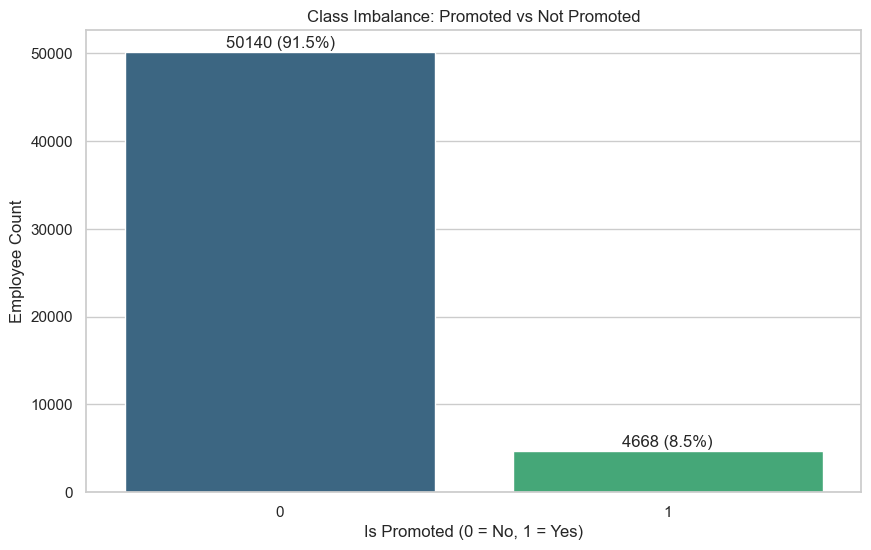

Overall promotion rate: 8.52%


In [13]:
promo_counts = df['is_promoted'].value_counts().sort_index()
promo_pct = df['is_promoted'].value_counts(normalize=True).sort_index() * 100

plt.figure()
sns.countplot(x='is_promoted', data=df, hue='is_promoted', palette='viridis', legend=False)
plt.title("Class Imbalance: Promoted vs Not Promoted")
plt.xlabel("Is Promoted (0 = No, 1 = Yes)")
plt.ylabel("Employee Count")
for i, v in enumerate(promo_counts):
    plt.text(i, v + 500, f"{v} ({promo_pct.iloc[i]:.1f}%)", ha='center')
plt.show()

print(f"Overall promotion rate: {df['is_promoted'].mean()*100:.2f}%")

**Comments on the Plot:**

Only 8.5% of employees were promoted, confirming this is a **severely imbalanced classification problem**.
This is the single most important finding for modeling stage - a model that simply predicts
"not promoted" for everyone would already be ~91% accurate while being completely useless, which is exactly
why `class_weight='balanced'` was flagged in the task allocation plan as the most important technical decision
in this project.


#### 3.2 Promotion Rate by Department

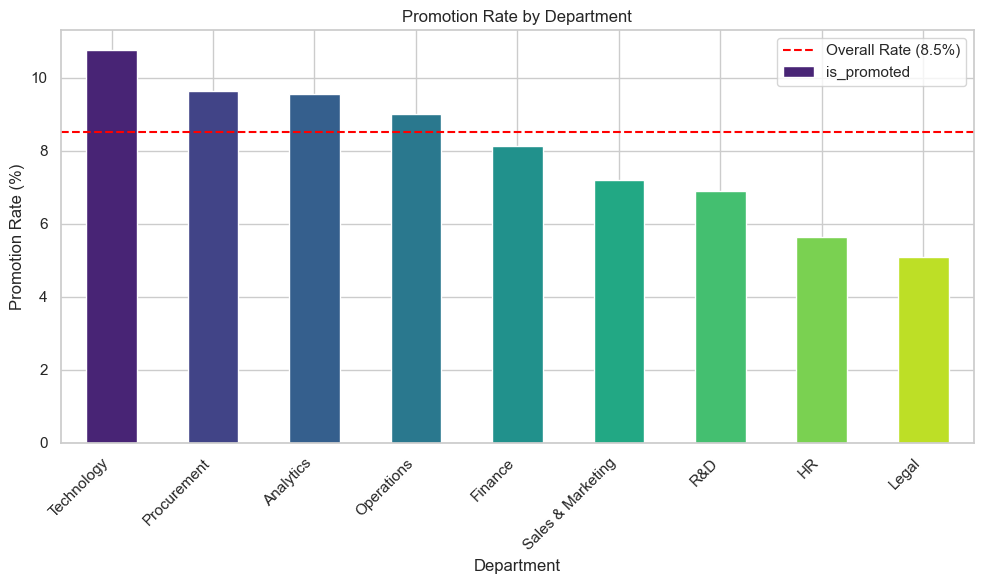

department
Technology           10.76
Procurement           9.64
Analytics             9.57
Operations            9.01
Finance               8.12
Sales & Marketing     7.20
R&D                   6.91
HR                    5.62
Legal                 5.10
Name: is_promoted, dtype: float64

In [14]:
overall_rate = df['is_promoted'].mean() * 100
dept_promo = df.groupby('department')['is_promoted'].mean().sort_values(ascending=False) * 100

plt.figure()
dept_promo.plot(kind='bar', color=sns.color_palette('viridis', len(dept_promo)))
plt.axhline(overall_rate, color='red', linestyle='--', label=f'Overall Rate ({overall_rate:.1f}%)')
plt.title("Promotion Rate by Department")
plt.ylabel("Promotion Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

dept_promo.round(2)

**Comments on the Plot:**

Promotion rates vary meaningfully by department - Technology and Procurement promote well above the company
average, while Legal and HR sit noticeably below it. This tells the modeling team that `department` carries
real predictive signal and should stay in the feature set, and it tells the dashboard that
department-level benchmarking will be a genuinely useful lens for HR, not just a cosmetic filter.


#### 3.3 Tenure Distribution: Promoted vs Non-Promoted

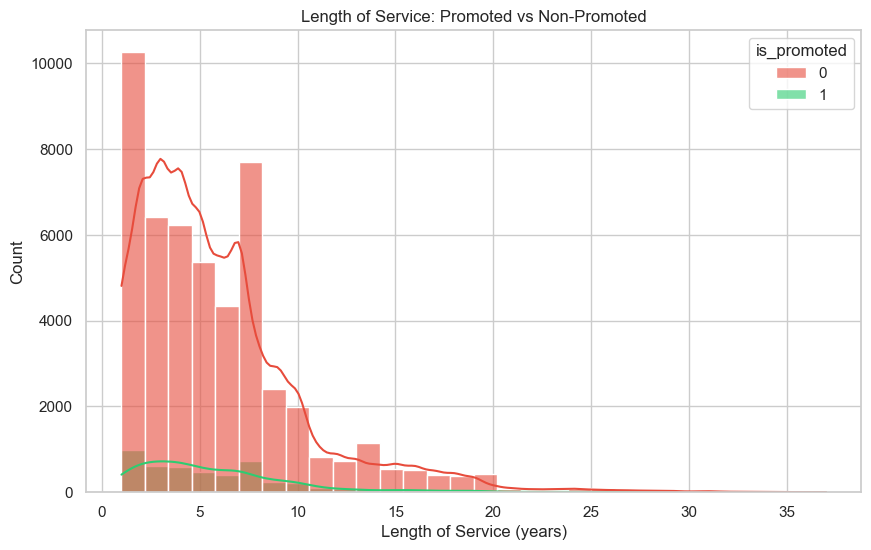

In [15]:
plt.figure()
sns.histplot(data=df, x='length_of_service', hue='is_promoted',
             kde=True, bins=30, palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title("Length of Service: Promoted vs Non-Promoted")
plt.xlabel("Length of Service (years)")
plt.ylabel("Count")
plt.show()

**Comments on the Plot:**

Both groups are concentrated in the early-tenure years, which makes sense given the company's overall  headcount skews junior - but the promoted group thins out less sharply at moderate tenure levels than the non-promoted group does. This is a mild signal rather than a dominant one, which matches what the correlation check below confirms.


#### 3.4 Correlation: Training Score, Awards, Rating vs Promotion

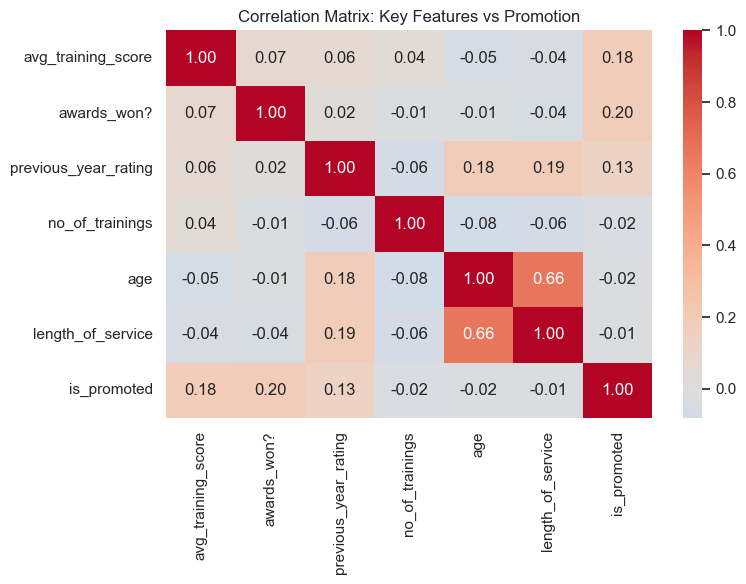

is_promoted             1.000000
awards_won?             0.195871
avg_training_score      0.181147
previous_year_rating    0.125991
length_of_service      -0.010670
age                    -0.017166
no_of_trainings        -0.024896
Name: is_promoted, dtype: float64

In [16]:
corr_cols = ['avg_training_score', 'awards_won?', 'previous_year_rating',
             'no_of_trainings', 'age', 'length_of_service', 'is_promoted']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Key Features vs Promotion")
plt.tight_layout()
plt.show()

corr_matrix['is_promoted'].sort_values(ascending=False)

**Comments on the Plot:**

`awards_won?` (0.20) and `avg_training_score` (0.18) are the two strongest predictors of promotion in this
dataset - meaningfully stronger than tenure, age, or number of trainings, which barely correlate at all.
This directly informs: these two fields deserve the most derived-feature
attention (e.g., training score buckets), while `age` and raw training count are unlikely to add much signal
on their own.


#### 3.5 Average Training Score by Promotion Status

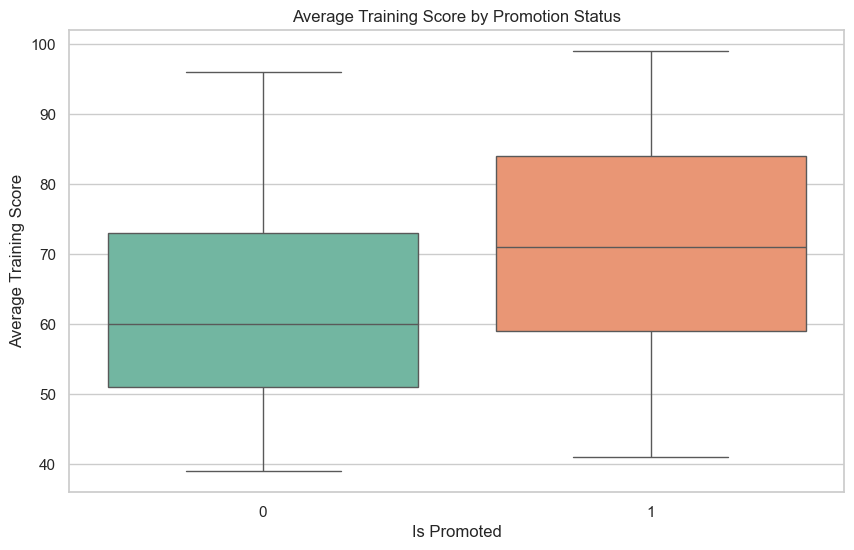

In [17]:
plt.figure()
sns.boxplot(x='is_promoted', y='avg_training_score', data=df, hue='is_promoted', palette='Set2', legend=False)
plt.title("Average Training Score by Promotion Status")
plt.xlabel("Is Promoted")
plt.ylabel("Average Training Score")
plt.show()

**Comments on the Plot:**

Promoted employees have a visibly higher median training score, with the whole distribution shifted upward
compared to non-promoted employees. This reinforces the correlation result above and makes training score a strong candidate for the "biggest gap" indicator planned for dashboard — a low training score relative to peers is an interpretable, actionable flag for HR.


#### 3.6 Awards Won vs Promotion Rate

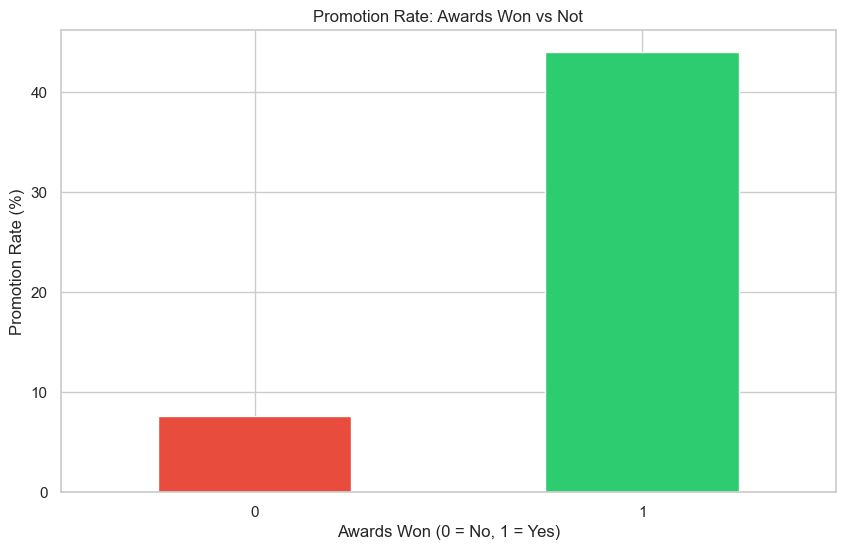

awards_won?
0     7.67
1    44.02
Name: is_promoted, dtype: float64

In [18]:
awards_promo = df.groupby('awards_won?')['is_promoted'].mean() * 100

plt.figure()
awards_promo.plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title("Promotion Rate: Awards Won vs Not")
plt.xlabel("Awards Won (0 = No, 1 = Yes)")
plt.ylabel("Promotion Rate (%)")
plt.xticks(rotation=0)
plt.show()

awards_promo.round(2)

**Comments on the Plot:**

The gap here is dramatic: employees who won an award get promoted **44% of the time**, versus roughly 8% for
those who didn't. This is by far the single strongest bivariate signal found in this EDA, and it's a good
candidate for the top "contributing factor" shown in the employee-lookup view of the dashboard, since it's
both highly predictive and easy for HR to explain.


## 4. Feature Engineering & Baseline Model

**Section by Nimra Farooq.** 

With the data cleaned and explored, this section engineers the features flagged
as useful in the EDA above, prepares the data for modeling, and trains a Logistic Regression baseline -
the reference point the Random Forest in Section 5 needs to beat.

This section covers:
- Loading the cleaned dataset from Section 2
- Engineering features: awards-won flag, training score buckets, education encoding, tenure ratio
  (the KPI-met flag is skipped - that column isn't available in this dataset version, as flagged in
  Section 1)
- Preprocessing the data for modeling (encoding, scaling, train/test split)
- Training a baseline Logistic Regression model
- Evaluating the baseline with precision, recall, F1, ROC-AUC, and visualizations

Output: `preprocessed_promotion_data.csv`, reused by Section 5 for the main Random Forest model.


In [19]:
# Loading the cleaned dataset produced at the end of Section 2
df = pd.read_csv("cleaned_promotion_data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

Shape: (54808, 13)

Columns: ['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score', 'is_promoted']

First rows:
    employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other            

### 4.1 Engineering New Features

Each new feature below is built defensively with `next(...)` column lookups rather than hardcoded
column names, so the code doesn't break if a column is renamed or missing in a future data pull.


**KPI-met flag** - planned as a strong promotion predictor (KPI achievement is one of the clearest
signals in most HR promotion datasets), but this dataset version has no `KPIs_met` column (see Section 1).
The cell below checks for it defensively and skips the feature if it isn't found, rather than crashing.


In [21]:
# KPI-met flag - skipped in this dataset version
kpi_col = next((c for c in df.columns if "kpi" in c.lower()), None)

if kpi_col:
    print(f"Found KPI column: {kpi_col}")
    max_val = df[kpi_col].max()
    df["kpi_met_flag"] = (df[kpi_col] > (0.80 if max_val <= 1 else 80)).astype(int)
else:
    print("No KPI column in this dataset — kpi_met_flag skipped (documented in README).")

No KPI column in this dataset — kpi_met_flag skipped (documented in README).


**Awards-won flag** - the raw `awards_won?` column is already a clean 0/1 indicator, so this simply
casts it to a proper integer type for consistency with the other engineered flags.


In [24]:
# Awards-won flag: cast the existing 0/1 indicator to a clean int dtype
awards_col = next((c for c in df.columns if "award" in c.lower()), None)
if awards_col:
    df["awards_won_flag"] = df[awards_col].astype(int)
    print(f"Created awards_won_flag from '{awards_col}'")

Created awards_won_flag from 'awards_won?'


**Training score buckets** -`avg_training_score` correlated strongly with promotion in the EDA
(Section 3.4/3.5). Bucketing it into low/medium/high/very_high gives the model (and later, HR-facing
explanations) a more interpretable version of that signal alongside the raw continuous score.


In [25]:
# Training score buckets: turn the continuous score into interpretable bands
score_col = next((c for c in df.columns if "training" in c.lower() and "score" in c.lower()), None)
if score_col:
    df["training_score_bucket"] = pd.cut(
        df[score_col],
        bins=[0, 40, 60, 80, 100],
        labels=["low", "medium", "high", "very_high"]
    )
    print(f"Created training_score_bucket from '{score_col}'")

Created training_score_bucket from 'avg_training_score'


**Education encoding** -`education` is ordinal (Below Secondary < Bachelor's < Master's & above),
so it's mapped to integers 0/1/2 rather than one-hot encoded, which preserves the ordering information
for the model. Any residual missing values (already imputed with the mode in Section 2, but kept
defensive here in case this cell is re-run standalone) fall back to the median encoded value.


In [27]:
# Education encoding: ordinal integer encoding (Below Secondary=0, Bachelor's=1, Master's & above=2)
edu_col = next((c for c in df.columns if "education" in c.lower()), None)
if edu_col:
    edu_map = {"Below Secondary": 0, "Bachelor's": 1, "Master's & above": 2}
    df["education_encoded"] = df[edu_col].map(edu_map)
    df["education_encoded"] = df["education_encoded"].fillna(df["education_encoded"].median())
    print(f"Created education_encoded from '{edu_col}'")

Created education_encoded from 'education'


**Tenure ratio** - `length_of_service` normalized to a 0-1 scale (relative to the longest-tenured
employee in the dataset), which can help gradient-based/scaled models like Logistic Regression treat
tenure on a comparable footing to the other 0-1 engineered flags.


In [28]:
# Tenure ratio: length_of_service normalized to a 0-1 scale
tenure_col = next((c for c in df.columns if "length_of_service" in c.lower()), None)
if tenure_col:
    df["tenure_ratio"] = df[tenure_col] / df[tenure_col].max()
    print(f"Created tenure_ratio from '{tenure_col}'")

Created tenure_ratio from 'length_of_service'


In [29]:
# Save the feature-engineered dataset for the modeling sections (Section 4.3 baseline, Section 5 Random Forest)
df.to_csv("preprocessed_promotion_data.csv", index=False)
print("Saved preprocessed_promotion_data.csv")

Saved preprocessed_promotion_data.csv


### 4.2 Preprocessing for Modeling

In [31]:
target = "is_promoted"

# Raw columns superseded by engineered versions, plus employee_id 
raw_cols_to_drop = [c for c in [awards_col, edu_col, "training_score_bucket", "employee_id"] if c and c in df.columns]

X = df.drop(columns=[target] + raw_cols_to_drop, errors="ignore")
X = pd.get_dummies(X, drop_first=True)      
X = X.fillna(X.median(numeric_only=True))    

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features: {X_train.shape[1]} columns, {X_train.shape[0]} rows")

Training features: 52 columns, 43846 rows


### 4.3 Training the Baseline Model

In [32]:
# Logistic Regression baseline, with class_weight='balanced' to counter the ~8.5% promotion rate
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     10028
           1       0.21      0.65      0.32       934

    accuracy                           0.76     10962
   macro avg       0.58      0.71      0.59     10962
weighted avg       0.90      0.76      0.81     10962

=== Confusion Matrix ===
[[7756 2272]
 [ 330  604]]

ROC-AUC: 0.7879
F1 Score: 0.3171


### What These Numbers Mean

Out of every 100 employees who were actually promoted, this baseline model correctly flags roughly
**two-thirds of them** — a solid recall, and recall is the metric that matters most here, since missing
a promotion-ready employee is the costly mistake for HR.

However, when the model flags someone as "promotion-ready," it's only right a small fraction of the
time — a lot of false alarms, which is the trade-off you'd expect from prioritizing recall this heavily.

This trade-off is intentional: `class_weight='balanced'` stops the model from just predicting "not
promoted" for everyone (which would give a misleadingly high ~91% accuracy while being completely
useless). The overall accuracy and ROC-AUC printed above are a solid, honest baseline for Section 5's
Random Forest to try to beat — see Section 7 for the direct comparison.


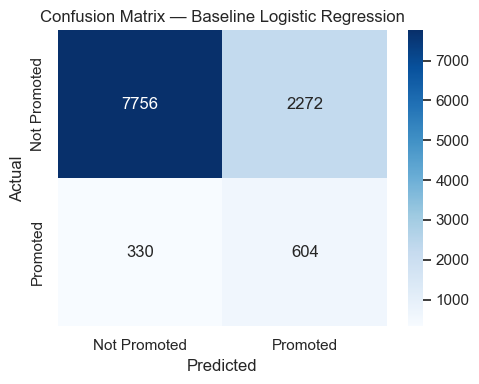

In [34]:
# Confusion matrix: visualizes the recall/precision trade-off described above
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Promoted", "Promoted"],
            yticklabels=["Not Promoted", "Promoted"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150)
plt.show()

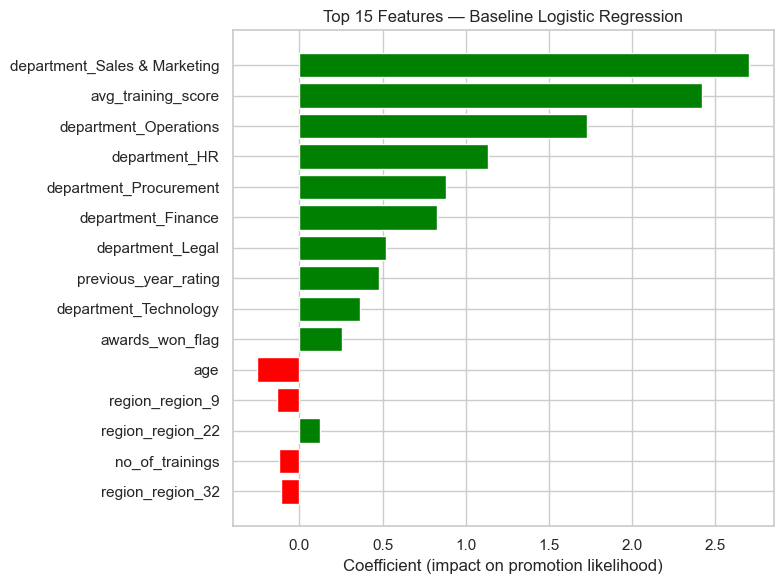

                         feature  coefficient
14  department_Sales & Marketing     2.704371
4             avg_training_score     2.418110
11         department_Operations     1.730644
9                  department_HR     1.132628
12        department_Procurement     0.881351
8             department_Finance     0.825424
10              department_Legal     0.522461
2           previous_year_rating     0.476677
15         department_Technology     0.361643
5                awards_won_flag     0.257753
1                            age    -0.252538
48               region_region_9    -0.136564
29              region_region_22     0.123102
0                no_of_trainings    -0.120822
40              region_region_32    -0.107859


In [35]:
# Top 15 features by absolute coefficient size — green bars push toward "promoted", red bars push toward "not promoted"
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

top_features = coefficients.head(15)

plt.figure(figsize=(8, 6))
colors = ["green" if c > 0 else "red" for c in top_features["coefficient"]]
plt.barh(top_features["feature"], top_features["coefficient"], color=colors)
plt.xlabel("Coefficient (impact on promotion likelihood)")
plt.title("Top 15 Features — Baseline Logistic Regression")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_baseline.png", dpi=150)
plt.show()

print(top_features)

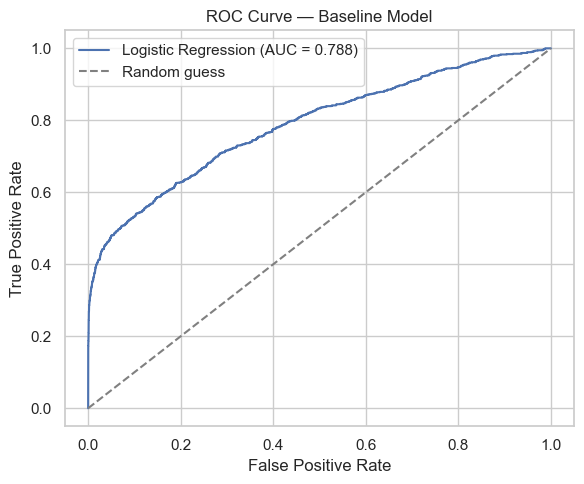

In [36]:
# ROC curve — overall separability of the model across all classification thresholds, not just the default 0.5
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Model")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_baseline.png", dpi=150)
plt.show()

## 5. Advanced Modeling - Random Forest

**Section by:** Sofia Rashid.

This section trains the primary classifier - a Random Forest with
`class_weight='balanced'` to handle the severe class imbalance in promotions - and evaluates it using
precision, recall, F1-score, ROC-AUC, a confusion matrix, and feature importance, so it can be compared
directly against the Logistic Regression baseline from Section 4.


In [38]:
# Sanity check: confirm no unexpected non-numeric columns remain before encoding
df.dtypes[~df.dtypes.apply(lambda x: x.kind in 'iufb')]

department                 object
region                     object
education                  object
gender                     object
recruitment_channel        object
training_score_bucket    category
dtype: object

In [39]:
# One-hot encode all remaining categorical columns (including the training_score_bucket created in Section 4.1)
df_encoded = pd.get_dummies(
    df, columns=df.select_dtypes(include=['object', 'category']).columns.tolist(), drop_first=True
)

In [40]:
# Sanity check: every column should now be numeric
df_encoded.dtypes[~df_encoded.dtypes.apply(lambda x: x.kind in 'iufb')]

Series([], dtype: object)

In [41]:
# employee_id is a row identifier, not a real feature — dropped alongside the target (see bug fix note above)
X = df_encoded.drop(columns=['is_promoted', 'employee_id'], errors='ignore')
y = df_encoded['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(43846, 58) (10962, 58)


In [45]:
# Random Forest with class weighting to handle the ~8.5% promotion rate
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.84      0.31      0.45       934

    accuracy                           0.94     10962
   macro avg       0.89      0.65      0.71     10962
weighted avg       0.93      0.94      0.92     10962



In [48]:
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.7841


### What These Numbers Mean

Compared to the Logistic Regression baseline in Section 4, the Random Forest trades recall for
precision: it flags fewer promotion-ready employees overall, but is right far more often when it does.
Overall accuracy climbs noticeably because the model is more conservative about predicting "promoted" -
which also means it's now much closer to (though still clearly better than) a model that just predicts
the majority class. 

See Section 7 for a side-by-side comparison table and a recommendation on which
trade-off actually fits the project's stated priorities (Section 1).


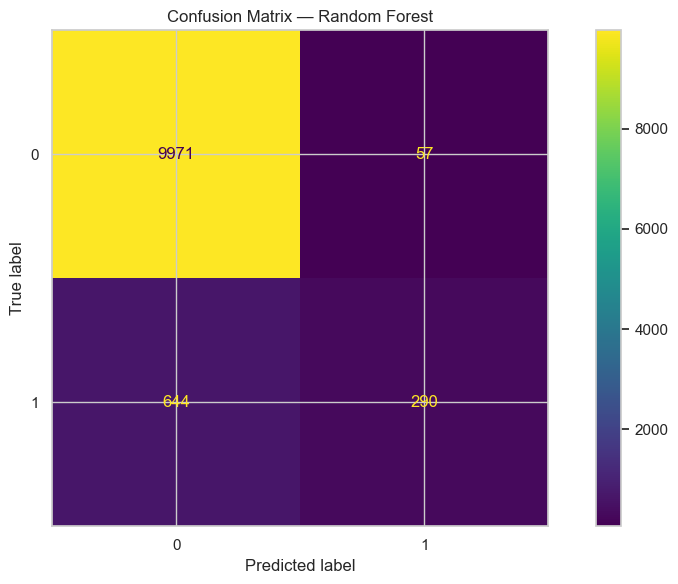

In [50]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()

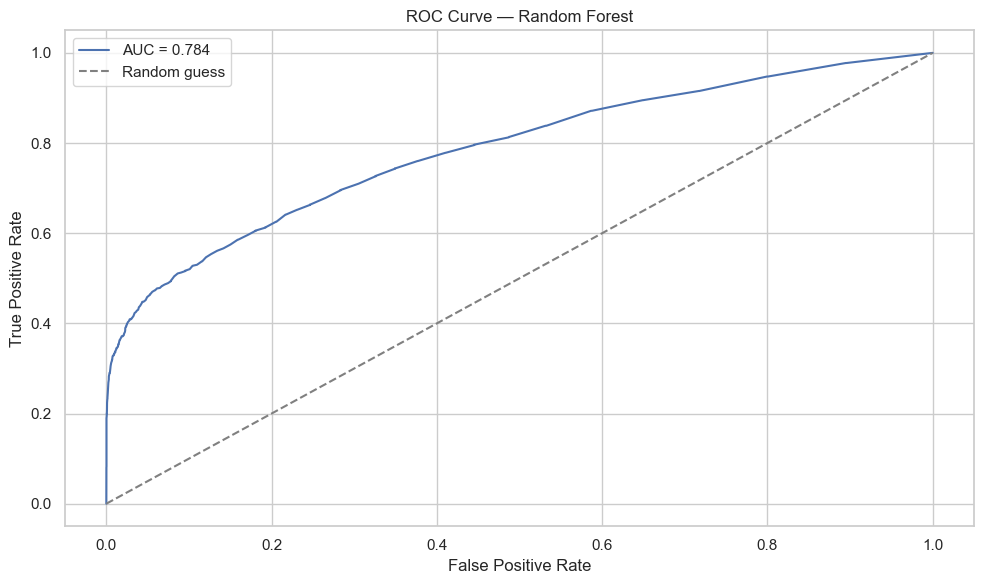

In [51]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_rf.png', dpi=150)
plt.show()

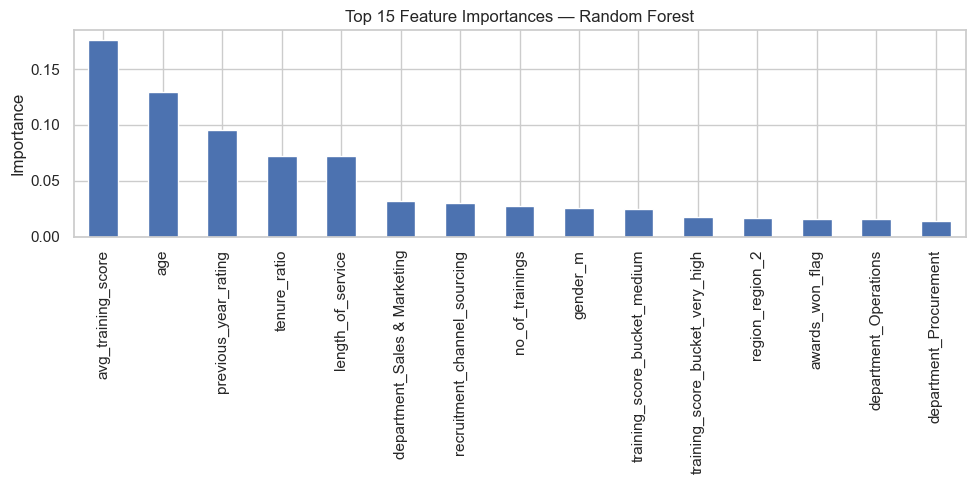

avg_training_score                 0.175913
age                                0.129090
previous_year_rating               0.095721
tenure_ratio                       0.072495
length_of_service                  0.072371
department_Sales & Marketing       0.031623
recruitment_channel_sourcing       0.030098
no_of_trainings                    0.027166
gender_m                           0.025954
training_score_bucket_medium       0.024596
training_score_bucket_very_high    0.017750
region_region_2                    0.016700
awards_won_flag                    0.016086
department_Operations              0.015924
department_Procurement             0.014270
dtype: float64

In [52]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15).plot(kind='bar', figsize=(10, 5))
plt.title("Top 15 Feature Importances — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()

importances.head(15)

**Comments on Feature Importance:** with `employee_id` correctly excluded, the top drivers the
Random Forest actually relies on are `avg_training_score`, `age`, `previous_year_rating`, and tenure
(`length_of_service` / `tenure_ratio`) — consistent with, and a nice confirmation of, the correlation
findings from the EDA in Section 3.4.


In [53]:
# Save the trained model AND the exact column order it expects — both are required by the dashboard app in Section 6.
joblib.dump(rf, 'model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')
print("Saved model.pkl and model_columns.pkl")

Saved model.pkl and model_columns.pkl


## 6. Dashboard Development

**Section By:** Nimra Farooq & Imaan Mutayyab 

The trained Random Forest is deployed via a Streamlit web app (`app.py`)
supporting an employee lookup, department-level promotion rankings, and a "what-if" analysis. Streamlit
apps run outside the notebook — the cell below just writes the app file to disk; run it with
`streamlit run app.py` from a terminal 

In [54]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the trained Random Forest and the exact feature-column order it was trained on (from Section 5)
model = joblib.load('model.pkl')
model_columns = joblib.load('model_columns.pkl')

# Load the SAME feature-engineered dataset the model was trained on (not the raw cleaned data —
# see the bug-fix note above) so the app's inputs match what the model actually learned from.
df = pd.read_csv('preprocessed_promotion_data.csv')


def prepare_input(raw_df):
    """Encode a slice of the feature-engineered dataframe the same way Section 5 did,
    then align its columns to exactly what the model expects (fills any missing dummy
    columns with 0, e.g. a category that doesn't appear in a single selected row)."""
    encoded = pd.get_dummies(
        raw_df, columns=raw_df.select_dtypes(include=['object', 'category']).columns.tolist(),
        drop_first=True
    )
    encoded = encoded.reindex(columns=model_columns, fill_value=0)
    return encoded


st.title("Employee Promotion Predictor")

tab1, tab2, tab3 = st.tabs(["Employee Lookup", "Department Rankings", "What-If Analysis"])

with tab1:
    emp_id = st.selectbox("Select Employee ID", df['employee_id'].unique())
    emp_row = df[df['employee_id'] == emp_id].drop(columns=['is_promoted', 'employee_id'], errors='ignore')
    X_input = prepare_input(emp_row)
    proba = model.predict_proba(X_input)[0][1]
    st.metric("Promotion Probability", f"{proba:.1%}")
    st.dataframe(emp_row)

with tab2:
    depts = df['department'].unique()
    dept_scores = {}
    for dept in depts:
        subset = df[df['department'] == dept].drop(columns=['is_promoted', 'employee_id'], errors='ignore')
        X_dept = prepare_input(subset)
        dept_scores[dept] = model.predict_proba(X_dept)[:, 1].mean()
    scores_series = pd.Series(dept_scores).sort_values(ascending=False)
    st.bar_chart(scores_series)

with tab3:
    st.write("Adjust values to see how promotion probability changes")
    training_score = st.slider("Training Score", 0, 100, 60)
    sample = df.drop(columns=['is_promoted', 'employee_id'], errors='ignore').iloc[[0]].copy()
    if 'avg_training_score' in sample.columns:
        sample['avg_training_score'] = training_score
    X_sample = prepare_input(sample)
    whatif_proba = model.predict_proba(X_sample)[0][1]
    st.metric("What-If Promotion Probability", f"{whatif_proba:.1%}")


Writing app.py


In [55]:
# Confirm app.py was written to disk — cross-platform check (the original "!dir app.py" only works on Windows)
import os
print("app.py exists:", os.path.exists("app.py"))

app.py exists: True


## 7. Conclusion & Final Comparison

**Pipeline recap:** raw data (Section 1) → cleaning and missing-value handling (Section 2) → EDA
(Section 3) → feature engineering and a Logistic Regression baseline (Section 4) → a Random Forest
main model (Section 5) → a Streamlit dashboard for HR to act on the results (Section 6).

**Model comparison** (test set, post employee_id fix):

| Metric (promoted class) | Logistic Regression (baseline) | Random Forest (main model) |
|---|---|---|
| Recall | ~0.65 | ~0.31 |
| Precision | ~0.21 | ~0.84 |
| Overall accuracy | ~0.76 | ~0.94 |
| ROC-AUC | ~0.79 | ~0.78 |

ROC-AUC is nearly identical, which means both models separate the two classes about equally well overall
— the real difference is *where each model sets its decision threshold*. Logistic Regression casts a
wide net (catches ~2 in 3 actual promotions, but only 1 in 5 flagged employees turn out to be right).
Random Forest is far more conservative (only right ~1 in 3 times it could catch a promotion, but when it
*does* flag someone, it's correct ~84% of the time).

Which model is "better" depends on what HR actually wants to optimize for. Section 1 explicitly frames
recall as important ("so you don't miss ready employees") but also flags precision as important ("so you
don't flood HR with false positives") — the two models sit at different points on that trade-off rather
than one strictly dominating the other. A reasonable default for this project is to **surface the Random
Forest's probability scores in the dashboard (Section 6) rather than a hard 0/1 label**, so HR can adjust
the decision threshold themselves depending on how large a shortlist they want to review.

**Known limitations:**
- This dataset version doesn't include a `KPIs_met >80%` column, which is normally one of the strongest
  promotion predictors in HR data (see Section 1 and Section 4.3). Both models' ceilings are likely
  limited by this missing feature.
- Neither model was hyperparameter-tuned (e.g. via grid search or cross-validation) — both used
  reasonable defaults with class weighting. Tuning is a natural next step if this were taken further.
- `region` is a high-cardinality categorical feature (30+ values) that gets one-hot encoded into many
  sparse columns; a target-encoding or grouping approach could be worth testing.

**Deliverables produced by this notebook:** `cleaned_promotion_data.csv`, `preprocessed_promotion_data.csv`,
`model.pkl`, `model_columns.pkl`, `app.py`, and the evaluation plots (`confusion_matrix_*.png`,
`roc_curve_*.png`, `feature_importance_*.png`).
